# ETA $\Large\eta$

In [213]:
import pandas as pd
import numpy as np

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly_express as px

# Define Library

In [215]:
lib = {
    'koran': (['chap_num', 'verse_num', 'token_num'], "./koran-TOKEN.csv", 1),
    'ajtzibab': (['para_id', 'line_id', 'token_num'], "../../notebooks/ajtzibab/ajtzibab-TOKEN.csv", 1),
    'christenson': (['chap_num', 'line_num', 'token_num'], "../../notebooks/christenson/christenson-TOKEN_QUC.csv", 1),
    'colop': (['parte', 'capit', 'token_num'], "../../notebooks/colop/colop-TOKEN.csv", 2),
    'christenson-quiche': (['para_num', 'sent_num', 'token_num'], "../../notebooks/ximenez-christenson/christenson-quiche-TOKEN.csv", 1)
}

In [216]:
LIB = pd.DataFrame(lib).T
LIB.columns = ['ohco', 'src_file', 'doc_ohco_level']
LIB.index.name = 'corpus_id'

In [217]:
LIB

,ohco,src_file,doc_ohco_level
corpus_id,,,
koran,"[chap_num, verse_num, token_num]",./koran-TOKEN.csv,1
ajtzibab,"[para_id, line_id, token_num]",../../notebooks/ajtzibab/ajtzibab-TOKEN.csv,1
christenson,"[chap_num, line_num, token_num]",../../notebooks/christenson/christenson-TOKEN_...,1
colop,"[parte, capit, token_num]",../../notebooks/colop/colop-TOKEN.csv,2
christenson-quiche,"[para_num, sent_num, token_num]",../../notebooks/ximenez-christenson/christenso...,1


In [218]:
def get_token_df(slug):
    # ohco = lib[slug][0]
    ohco = LIB.loc[slug, 'ohco']
    return pd.read_csv(lib[slug][1]).set_index(ohco)[['token_str', 'term_str']]

# Check out text

In [219]:
slug = 'christenson'
# slug = 'ajtzibab'
# slug = 'colop'
# slug = 'christenson-quiche'
TOKEN = get_token_df(slug)

# Create Corpus

In [220]:
import importlib
import eta as ŋ
importlib.reload(ŋ)

ŋ.export_dir = "./export"

corpus = ŋ.Corpus(TOKEN, list(TOKEN.index.names), slug=slug)
corpus.extract_vocab()
for c in [40, 50, 60, 80, 100]:
    corpus.add_chunk_col(c)
corpus.export_data()

In [221]:
# chap.DOC_IDX

# Create chap and chunk Docs

In [222]:
ohco_offset = LIB.loc[slug, 'doc_ohco_level']
doc_cols = LIB.loc[slug, 'ohco'][:ohco_offset]

In [223]:
doc_cols

['chap_num']

In [224]:
# chap = ŋ.Doc(corpus, group_cols=doc_cols, doc_name='chap')
# chap.make_bow_df()
# chap.make_count_matrix()
# chap.compute_term_significance()
# chap.define_sig_terms(agg_func='median')
# chap.make_tfidf_df()
# chap.compute_pca()
# chap.export_data()

In [266]:
c_num = 60
chunk = ŋ.Doc(corpus, group_cols=[f'chunk_{c_num}_id'], doc_name='chunk60')
chunk.make_bow_df()
chunk.make_count_matrix()
chunk.compute_term_significance()
chunk.define_sig_terms(agg_func='mean')
chunk.make_tfidf_df()
chunk.compute_pca()
chunk.export_data()

# Cluster Docs

### By Chap

In [267]:
# chap_cluster = ŋ.Cluster(chap)
# chap_cluster.metric = 'euclidean'
# chap_cluster.make_tfidf_dist_df()

In [268]:
# sns.clustermap(chap_cluster.X, col_cluster=False, cmap="YlGnBu_r");

In [269]:
# chap_cluster.cluster_tfidf()
# chap_cluster.show_tree(.22)

In [270]:
# chap_cluster.get_clusters()
# chap_cluster.assign_cluster_tfidf_values()
# chap_cluster.create_cluster_model()

In [271]:
# px.imshow(chap_cluster.CLUSTER_MODEL,
#          color_continuous_scale=px.colors.carto.Aggrnyl, 
#          title=f"{chap_cluster.doc.corpus.slug.capitalize()} {chap_cluster.doc.doc_name.upper()} clusters with Δ = {chap_cluster.tfidf_hac.color_thresh}")

In [272]:
# chap_cluster.export_data()

### By Chunk

In [273]:
chunk_cluster = ŋ.Cluster(chunk)
chunk_cluster.make_tfidf_dist_df()
chunk_cluster.metric = 'euclidean'

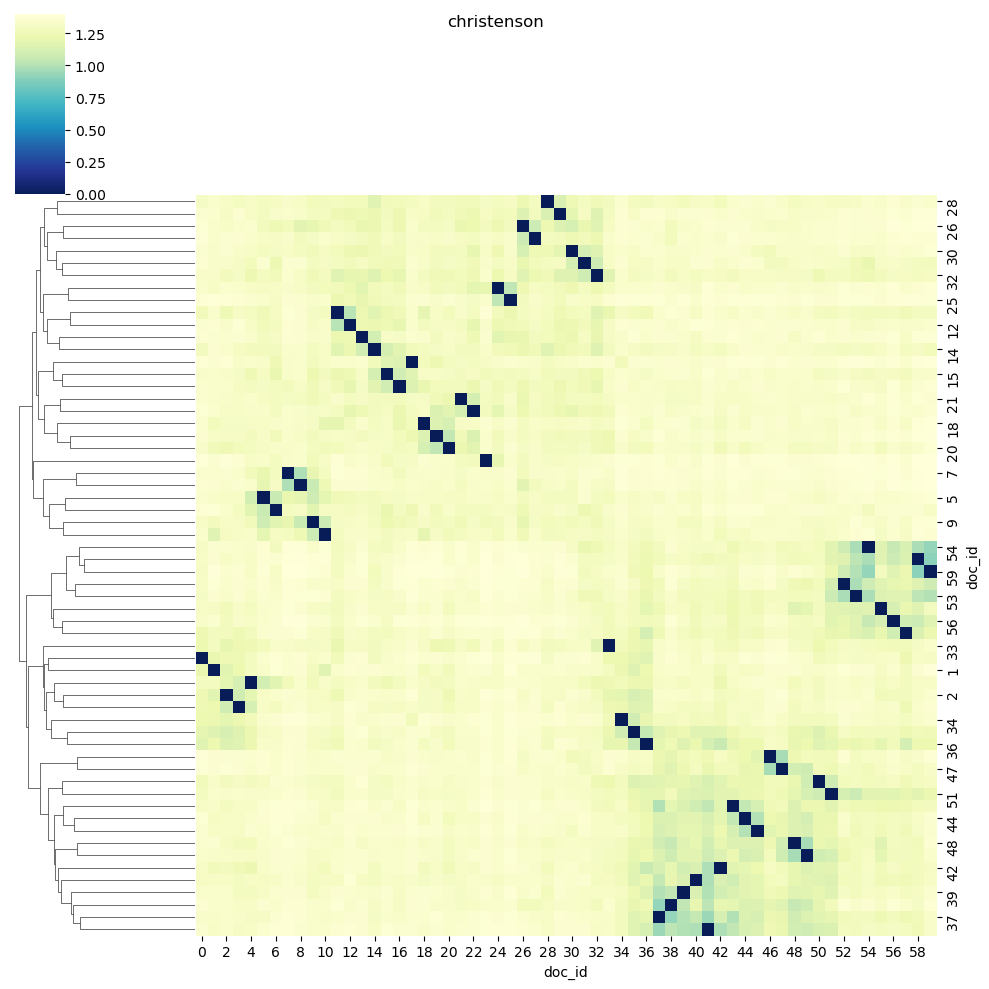

In [274]:
sns.clustermap(chunk_cluster.X, col_cluster=False, cmap="YlGnBu_r").fig.suptitle(slug);

<Figure size 640x480 with 0 Axes>

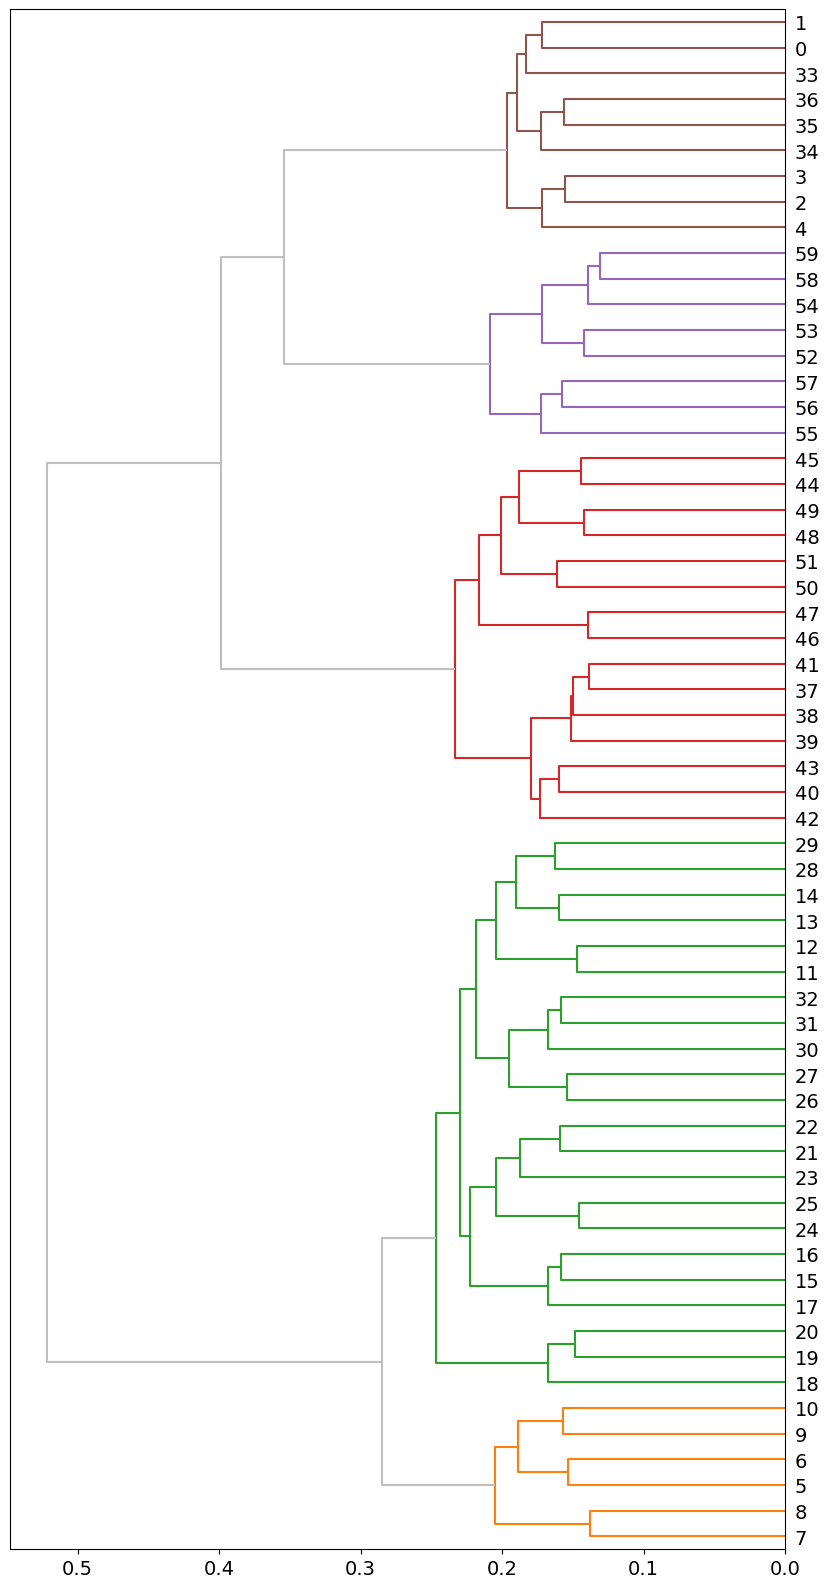

In [275]:
chunk_cluster.cluster_tfidf()
chunk_cluster.show_tree(.28)

In [276]:
chunk_cluster.get_clusters()
chunk_cluster.assign_cluster_tfidf_values()
chunk_cluster.create_cluster_model()

In [277]:
chunk_cluster.CLUSTER.top_terms

cluster_letter
A              kaj, aj, b'it, winaq, tz'aq, ulew, wach
B    k'ajolab', sipakna, kaqix, kab'raqan, wuqub', ...
C    xib'alb'a, kame, junajpu, xcha', xecha', kik',...
D    b'alam, amaq', tojil, kitze, b'i', majukutaj, ...
E             ajaw, ajawab', ja, aj, pop, nim, tinamit
Name: top_terms, dtype: object

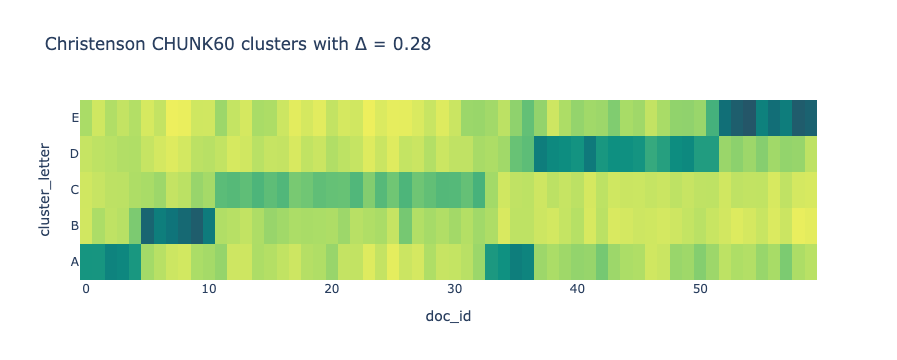

In [278]:
px.imshow(chunk_cluster.CLUSTER_MODEL.T.sort_index(ascending=False),
         color_continuous_scale=px.colors.carto.Aggrnyl, 
         title=f"{chunk_cluster.doc.corpus.slug.capitalize()} {chunk_cluster.doc.doc_name.upper()} clusters with Δ = {chunk_cluster.tfidf_hac.color_thresh}")\
    .update_layout(coloraxis_showscale=False)

In [279]:
chunk_cluster.export_data()

# Topic Models

## Chap Model

In [280]:
# chap_model = ŋ.Model(chap)
# # chap_model.alter_k(chap_cluster.k)
# chap_model.alter_k(6)
# chap_model.alpha_W = .1
# chap_model.alpha_H = 0
# chap_model.l1_ratio = 0
# chap_model.compute_topics()

In [281]:
# chap_model.TOPIC.top_terms

In [282]:
# px.imshow(chap_model.THETA.T.sort_index(ascending=False), width=1000, 
#           color_continuous_scale=px.colors.diverging.Spectral, 
#           color_continuous_midpoint=0).update_layout(coloraxis_showscale=False)

## Chunk Model

In [283]:
chunk_model = ŋ.Model(chunk)
chunk_model.alter_k(chunk_cluster.k)
# chunk_model.alter_k(5)
chunk_model.alpha_W = .1
chunk_model.alpha_H = 0
chunk_model.l1_ratio = 0
chunk_model.compute_topics()

In [284]:
chunk_model.TOPIC.top_terms

topic_letter
A    b'it, k'ajolom, alom, xpiyakok, b'itol, tz'aqo...
B    sipakna, lal, jul, kaqix, kab'raqan, k'ajolab'...
C    kame, chowen, b'atz', xib'alb'a, ch'o, kotz'i'...
D    amaq', tojil, q'apojib', tulan, k'ixb', jaq'aw...
E    pop, q'alel, ajawarem, k'iq'ab', ismachi', tuj...
Name: top_terms, dtype: object

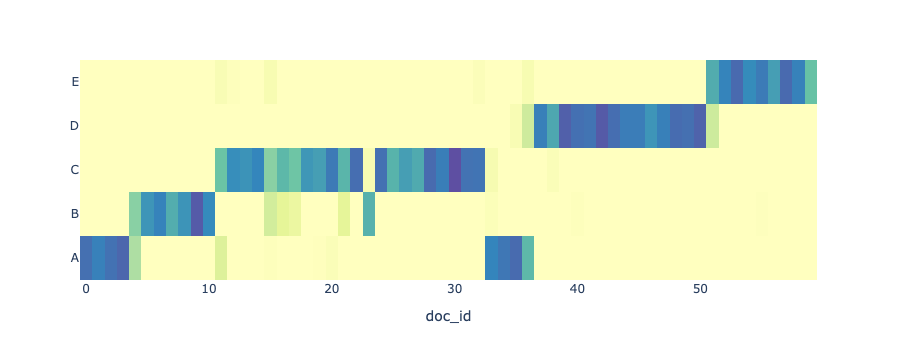

In [285]:
px.imshow(chunk_model.THETA.T.sort_index(ascending=False), 
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0).update_layout(coloraxis_showscale=False)

## Apply Chunk Model to Chap

In [286]:
chunk_model.apply_model(doc_cols)

### Using Phi

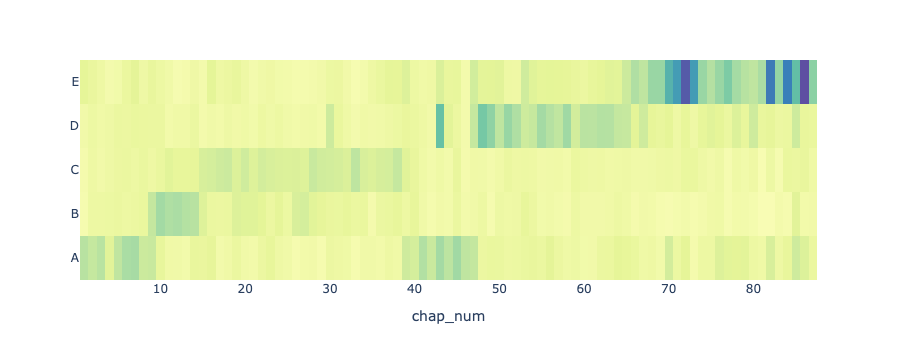

In [287]:
px.imshow(chunk_model.DOC2_TOPIC_PHI.T.sort_index(ascending=False), 
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0
         ).update_layout(coloraxis_showscale=False)

### Using Theta

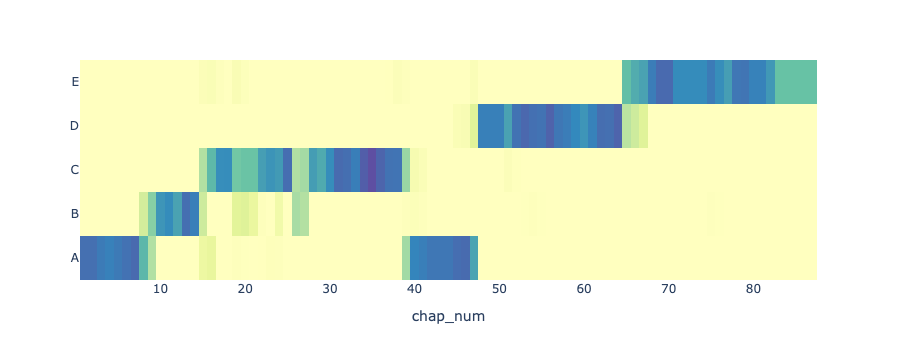

In [288]:
px.imshow(chunk_model.DOC2_TOPIC_THETA.T.sort_index(ascending=False),  
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0
         ).update_layout(coloraxis_showscale=False)

# Save

In [289]:
# chap_model.export_data()

In [290]:
chunk_model.export_data()

No table THETA_SEQ


# Play

In [291]:
list(ascii_uppercase[:len(chunk_cluster.CLUSTER)])

NameError: name 'ascii_uppercase' is not defined

In [ ]:
len(chunk_cluster.CLUSTER)

In [296]:
V = corpus.VOCAB.join(chunk.VOCAB)

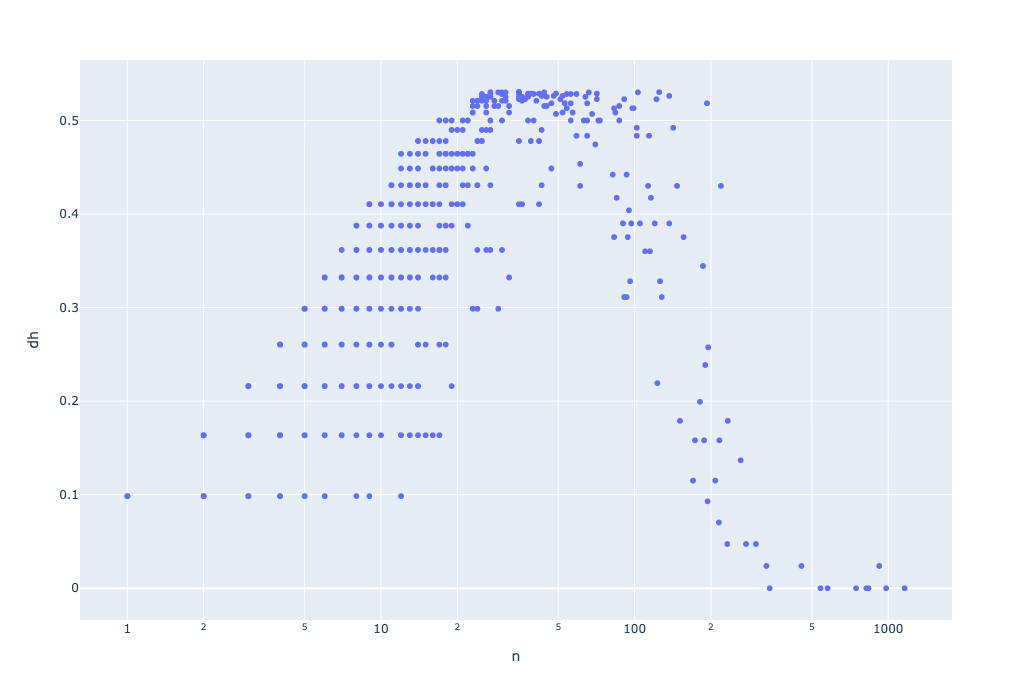

In [313]:
px.scatter(V, 'n', 'dh', log_x=True, height=700, hover_name=V.index)

In [321]:
(V.dh.mean().round(3), V.dh.median().round(3))

(0.156, 0.098)